# **AutoFix Pro**

El taller AutoFix Pro realiza diariamente:

Reparaciones mecánicas

*   Reparaciones mecánicas

*   Revisiones periódicas

*   Cambios de neumáticos

*   Diagnósticos electrónicos










El control del tiempo y del estado de los servicios es fundamental para:


*   Reducir retrasos
*   Mejorar la planificación diaria
*   Optimizar la rentabilidad de cada servicio









Los problemas para resolución y optimizacion son los siguientes:





*   No existen indicadores claros de rendimiento
*   No se analizan los tiempos por tipo de servicio
*   No se anticipan retrasos ni sobrecostes









Para el proyecto AutoFix Pro se utiliza un conjunto de datos propio, registrado y gestionado en Microsoft Excel, que simula la actividad diaria del taller mecánico.

Se recoge información detallada de los servicios realizados en el taller, incluyendo datos productivos y económicos relevantes para el análisis del rendimiento.

Cada fila representa un servicio realizado, y cada columna corresponde a una variable clave del proceso productivo.

*   ID_Servicio: Identificador único del      servicio.

*   Fecha: Fecha en la que se realizó el servicio.

*   Tipo_Servicio: Clasificación del trabajo realizado.

*   Mecanico: Técnico responsable del servicio.

*  Tiempo_Estimado: Número de horas estimadas en la ejecución del trabajo.

*  Tiempo_Real: Número de horas reales empleadas en la ejecución del trabajo.

*  Estado: Indica si el servicio fue Finalizado en plazo o Retrasado.

*  Coste: Coste interno asociado al servicio.

*  Ingreso: Importe facturado al cliente.

*  Beneficio: Diferencia entre ingreso y coste.

In [ ]:
import pandas as pd
df=pd.read_excel('AutoFix_Pro.xlsm')

Se analiza la información general del conjunto de datos para comprobar:

In [ ]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)
print(f"Total de valores nulos: {nulos.sum()}")
if nulos.sum() > 0:
    df = df.dropna()
    print(f"Filas eliminadas: {nulos.sum()}")
else:
    print("No hay valores nulos, no es necesario eliminar filas.")

Valores nulos por columna:
ID_Servicio        0
Fecha              0
Tipo_Servicio      0
Mecanico           0
Tiempo_Estimado    0
Tiempo_Real        0
Estado             0
Coste              0
Ingreso            0
Beneficio          0
dtype: int64
Total de valores nulos: 0
No hay valores nulos, no es necesario eliminar filas.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID_Servicio      200 non-null    object        
 1   Fecha            200 non-null    datetime64[ns]
 2   Tipo_Servicio    200 non-null    object        
 3   Mecanico         200 non-null    object        
 4   Tiempo_Estimado  200 non-null    float64       
 5   Tiempo_Real      200 non-null    float64       
 6   Estado           200 non-null    object        
 7   Coste            200 non-null    float64       
 8   Ingreso          200 non-null    float64       
 9   Beneficio        200 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 15.8+ KB


Para asegurar que los cálculos se realicen correctamente, se convierten las columnas al tipo adecuado

In [ ]:
df["Fecha"] = pd.to_datetime(df["Fecha"])

Para facilitar el análisis posterior, se crean nuevas variables:

In [ ]:
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

Función para la clasificación por la duracion del servicio:

In [ ]:
def clasificar_duracion(horas):
    if horas <= 1.5:
        return "Corta"
    elif horas <= 3:
        return "Media"
    else:
        return "Larga"

df["Duracion_Servicio"] = df["Tiempo_Real"].apply(clasificar_duracion)

In [ ]:
df.head()

,ID_Servicio,Fecha,Tipo_Servicio,Mecanico,Tiempo_Estimado,Tiempo_Real,Estado,Coste,Ingreso,Beneficio,Año,Mes,Duracion_Servicio
0,SRV-0001,2024-11-24,Reparación Mecánica,Carlos López,4.2,4.9,Retrasado,92.30,149.56,57.26,2024,11,Larga
1,SRV-0002,2024-10-07,Reparación Mecánica,Miguel Torres,3.3,4.1,Retrasado,140.64,177.67,37.03,2024,10,Larga
2,SRV-0003,2024-04-12,Diagnóstico Electrónico,Ana Martínez,1.4,3.2,Retrasado,77.94,103.65,25.71,2024,4,Larga
3,SRV-0004,2024-08-05,Cambio Neumáticos,Pedro Sánchez,1.2,1.1,Finalizado en plazo,56.49,73.34,16.85,2024,8,Corta
4,SRV-0005,2024-06-26,Cambio Neumáticos,Carlos López,2.1,2.2,Finalizado en plazo,76.50,116.74,40.24,2024,6,Media


Gestión de la información:

Se examina la distribución de los servicios según su estado para saber qué porcentaje han sido finalizados en plazo y cuántos han sufrido retrasos.

In [ ]:
conteo = df["Estado"].value_counts()
porcentaje = df["Estado"].value_counts(normalize=True).mul(100).round(1)

resumen_estado = pd.DataFrame({
    "Nº Servicios" : conteo,
    "% del total"  : porcentaje.astype(str) + " %"
})
print(resumen_estado)

                     Nº Servicios % del total
Estado                                       
Finalizado en plazo           133      66.5 %
Retrasado                      67      33.5 %


Se agrupan los servicios por tipo para comparar el volumen de trabajo, los ingresos y beneficios generados, y el tiempo medio empleado en cada categoría.

In [ ]:
df.groupby("Tipo_Servicio").agg(
    Servicios       = ("ID_Servicio", "count"),
    Ingreso_Total   = ("Ingreso", "sum"),
    Beneficio_Total = ("Beneficio", "sum"),
    Tiempo_Medio    = ("Tiempo_Real", "mean")
).round(2).style.format({
    "Ingreso_Total"   : "{:,.2f} €",
    "Beneficio_Total" : "{:,.2f} €",
    "Tiempo_Medio"    : "{:.2f} h"
})

,Servicios,Ingreso_Total,Beneficio_Total,Tiempo_Medio
Tipo_Servicio,,,,
Cambio Neumáticos,45,"6,028.43 €","2,056.03 €",2.07 h
Diagnóstico Electrónico,47,"4,587.71 €","1,502.44 €",1.88 h
Reparación Mecánica,61,"12,089.01 €","3,986.20 €",3.84 h
Revisión Periódica,47,"3,818.20 €","1,366.22 €",1.15 h


Se analiza el rendimiento individual de cada técnico en servicios realizados, beneficio aportado y tiempo medio por servicio.

In [ ]:
df.groupby("Mecanico").agg(
    Servicios       = ("ID_Servicio", "count"),
    Beneficio_Total = ("Beneficio", "sum"),
    Tiempo_Medio    = ("Tiempo_Real", "mean")
).round(2).style.format({
    "Beneficio_Total" : "{:,.2f} €",
    "Tiempo_Medio"    : "{:.2f} h"
})

,Servicios,Beneficio_Total,Tiempo_Medio
Mecanico,,,
Ana Martínez,32,"1,356.74 €",2.31 h
Carlos López,37,"1,597.04 €",2.51 h
Laura Gómez,40,"1,643.80 €",2.10 h
Miguel Torres,44,"2,300.29 €",2.79 h
Pedro Sánchez,47,"2,013.02 €",2.05 h


KPI Beneficio:
El taller AutoFix Pro ha generado un beneficio total de 8.910,89 € en 2024, situándose por debajo del objetivo establecido de 9.500 €

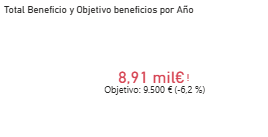

KPI % Retrasados:
El 33,5% de los servicios realizados en 2024 han sufrido retrasos, superando el umbral objetivo del 20%, lo que señala la gestión de tiempos como el principal aspecto a optimizar en el taller.

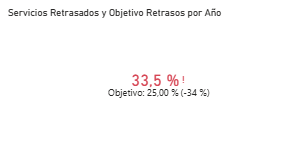

Gráfico Beneficio por mecánico:
El gráfico refleja el beneficio económico aportado por cada técnico en 2024, siendo Miguel Torres el mecánico más rentable para el taller con el mayor beneficio generado.

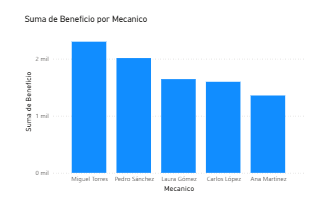

Gráfico Servicios por tipo:
El gráfico muestra la distribución del volumen de trabajo entre los cuatro tipos de servicio, siendo la Reparación Mecánica el servicio más demandado con un 30,5% del total de trabajos realizados.

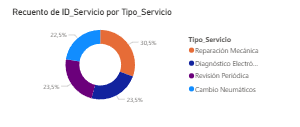

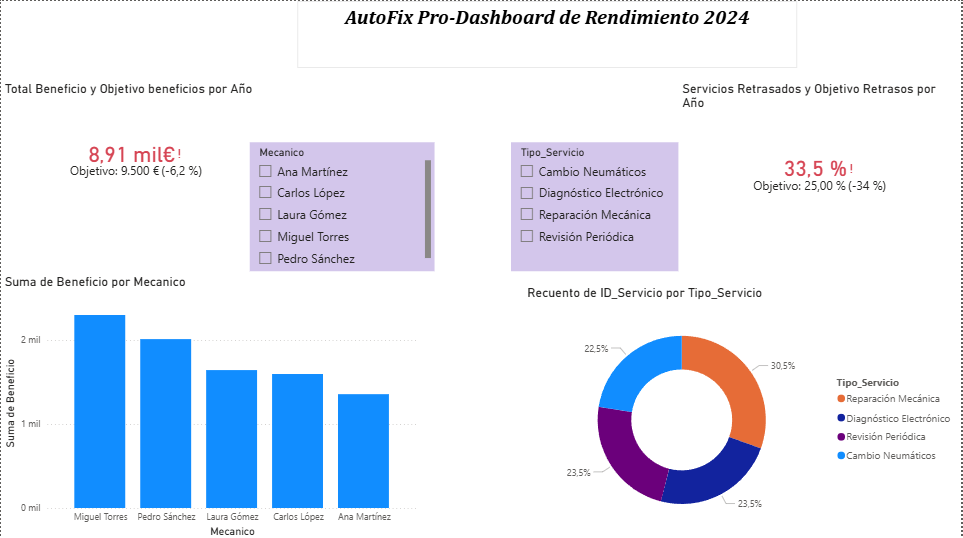

Automatizacion de carga del archivo, eliminacion de nulos, eliminacion de duplicados y conversion de fecha:

In [ ]:
def limpiar_datos():


    df = pd.read_excel("AutoFix_Pro.xlsm")


    df = df.dropna()
    df = df.drop_duplicates()


    df["Fecha"] = pd.to_datetime(df["Fecha"])

    print(f"Limpieza completada: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

df = limpiar_datos()

Limpieza completada: 200 filas x 10 columnas


Se automatiza el análisis de los datos del taller mediante una función que calcula de forma automática el beneficio medio por tipo de servicio y el número de retrasos por mecánico:

In [ ]:
def analisis_avanzado(df):


    beneficio_medio = df.groupby("Tipo_Servicio")["Beneficio"].mean().round(2)
    print("Beneficio medio por tipo de servicio:")
    print(beneficio_medio)
    print()


    retrasos = df[df["Estado"] == "Retrasado"].groupby("Mecanico").size()
    print("Retrasos por mecánico:")
    print(retrasos)

    return beneficio_medio, retrasos


In [ ]:
analisis_avanzado(df)

Beneficio medio por tipo de servicio:
Tipo_Servicio
Cambio Neumáticos          45.69
Diagnóstico Electrónico    31.97
Reparación Mecánica        65.35
Revisión Periódica         29.07
Name: Beneficio, dtype: float64

Retrasos por mecánico:
Mecanico
Ana Martínez     14
Carlos López     16
Laura Gómez       9
Miguel Torres    15
Pedro Sánchez    13
dtype: int64


(Tipo_Servicio
 Cambio Neumáticos          45.69
 Diagnóstico Electrónico    31.97
 Reparación Mecánica        65.35
 Revisión Periódica         29.07
 Name: Beneficio, dtype: float64,
 Mecanico
 Ana Martínez     14
 Carlos López     16
 Laura Gómez       9
 Miguel Torres    15
 Pedro Sánchez    13
 dtype: int64)

Se implementa un modelo de regresión lineal para predecir el beneficio de un servicio en función del tiempo real empleado, permitiendo al taller anticipar la rentabilidad antes de realizar el trabajo.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# X es la "causa" (Tiempo_Real) e Y es el "efecto" (Beneficio)
X = df[["Tiempo_Real"]]
y = df["Beneficio"]

modelo = LinearRegression()
modelo.fit(X, y)

# Predecir el beneficio si el próximo servicio dura 4 horas
horas_futuras = np.array([[4]])
prediccion_beneficio = modelo.predict(horas_futuras)

print("--- RESULTADO DEL ANÁLISIS DE IA ---")
print(f"Para un servicio de 4h, el beneficio estimado es de: {prediccion_beneficio[0]:.2f} €")

# Precision de la tendencia
precision = modelo.score(X, y)
print(f"Fiabilidad del modelo basada en datos históricos: {precision * 100:.2f}%")

--- RESULTADO DEL ANÁLISIS DE IA ---
Para un servicio de 4h, el beneficio estimado es de: 58.74 €
Fiabilidad del modelo basada en datos históricos: 24.66%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Interpretación de los resultados**

Durante el desarrollo del proyecto se ha analizado la actividad del taller AutoFix Pro a lo largo de 2024, registrando un total de 200 servicios. El análisis de los datos ha permitido extraer las siguientes conclusiones:

El taller ha generado un beneficio total de 8.910,89 €, lo que representa un margen medio del 33%. Sin embargo este beneficio se sitúa por debajo del objetivo establecido de 9.500 €, indicando que existe margen de mejora en la rentabilidad del negocio.

El servicio más demandado ha sido la Reparación Mecánica con 61 servicios, representando el 30,5% del total y siendo además el que mayor ingreso global genera. Por el contrario la Revisión Periódica es el servicio con menor tiempo medio empleado, lo que la convierte en el trabajo más eficiente en relación tiempo-beneficio.

En cuanto al rendimiento por mecánico, Miguel Torres ha sido el técnico más rentable generando el mayor beneficio, mientras que Ana Martínez y Carlos López presentan las tasas de retraso más elevadas, superando ambos el 40%.

El dato más relevante del análisis es que el 33,5% de los servicios han sufrido retrasos, más del doble del objetivo establecido del 20%, lo que señala la gestión de tiempos como el principal problema del taller.

El modelo predictivo de regresión lineal ha confirmado que existe una relación directa entre el tiempo empleado y el beneficio generado, permitiendo estimar la rentabilidad de futuros servicios antes de realizarlos.

**Propuesta de mejoras**

A partir de los resultados obtenidos se proponen las siguientes mejoras:

1. Reducir la tasa de retrasos:
    Dado que el 33,5% de los servicios se retrasan, se recomienda revisar la planificación diaria del taller y establecer tiempos estimados más realistas por tipo de servicio, prestando especial atención a las Reparaciones Mecánicas que son las que más retrasos acumulan.

2.  Formación específica para Ana Martínez y Carlos López:
    Al presentar tasas de retraso superiores al 40%, se recomienda analizar sus métodos de trabajo y proporcionarles formación o apoyo para mejorar su eficiencia.
    
3. Aumentar el volumen de Revisiones Periódicas
    Al ser el servicio más rápido y con buen margen, incrementar su volumen permitiría aumentar el beneficio total sin necesidad de aumentar el tiempo de trabajo.